In [349]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re

In [350]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
import plotting
import utils

In [351]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
TEST_BATCH_RUNS_FOLDER = os.path.join(BATCH_RUNS_FOLDER, "test")

In [352]:
batch_name = "37-v0-v1-v2-v3"
batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [353]:
test_folders = [
    os.path.join(TEST_BATCH_RUNS_FOLDER, f) for f in os.listdir(TEST_BATCH_RUNS_FOLDER)
]
batch_folder_names = [
    "Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT",
    "Apr08_Tue_h11-GTSEP_v1a_multi-37_ES_PT",
]

folders_to_explore = [os.path.join(SINGLE_RUNS_FOLDER, f) for f in batch_folder_names]
folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h11-GTSEP_v1a_multi-37_ES_PT']

In [354]:
# Setup the folders to explore and their display name
folder1 = os.path.join(BATCH_RUNS_FOLDER, "1_GTSEP_v0-No name-Feb18_Tue_h08")
folder2 = os.path.join(BATCH_RUNS_FOLDER, "2_GTSEP_v1-No name-Feb18_Tue_h08")
folder3 = os.path.join(SINGLE_RUNS_FOLDER, "GTSEP_v2-No name-Feb19_Wed_h09")
# results_folders_to_explore = [folder1, folder2,folder3]
results_folders_to_explore = folders_to_explore
display_names = ["Old", "New"]
MAX_COLUMNS = 2

# Alternatively explore all folders in a batch directory

## Figures

In [355]:
def categorize_png_files(folder):
    figures_path = os.path.join(folder, "results", "figures")
    categorized_files = {
        "grid": [],
        "bar": [],
        "battery_general": [],
        "battery_hourly_soc": [],
        "battery_city_soc": [],
        "remaining": [],
    }

    for root, _, files in os.walk(figures_path):
        for file in files:
            if file.endswith(".png"):
                relative_path = os.path.relpath(os.path.join(root, file), figures_path)

                # Normalize to use forward slashes for regex compatibility
                relative_path = relative_path.replace("\\", "/")

                # Grid figures
                if relative_path.startswith("grid"):
                    categorized_files["grid"].append(relative_path)

                # Bar figures
                elif relative_path.startswith("bar"):
                    categorized_files["bar"].append(relative_path)

                # Battery subfolder
                elif "batteries" in relative_path:
                    if re.match(
                        r"batteries/\d+_plot_battery_average_hourly_soc_month_",
                        relative_path,
                    ):
                        categorized_files["battery_hourly_soc"].append(relative_path)
                    elif re.match(
                        r"batteries/[A-Za-z]+_plot_battery_average_hourly_soc_by_month_",
                        relative_path,
                    ):
                        categorized_files["battery_city_soc"].append(relative_path)
                    else:
                        categorized_files["battery_general"].append(relative_path)

                # Remaining figures
                else:
                    categorized_files["remaining"].append(relative_path)

    return categorized_files


# Get categorized PNG files from the first folder
reference_folder = results_folders_to_explore[0]
png_categories = categorize_png_files(reference_folder)


# Function to display grouped images
def display_images(image_group, title):
    print("=" * 80)
    print(f"Showing: {title}")
    print("=" * 80)

    if not image_group:
        print(f"No images found for {title}.")
        return

    num_folders = len(results_folders_to_explore)
    num_rows = math.ceil(
        num_folders / MAX_COLUMNS
    )  # Dynamically calculate number of rows

    for png_file in image_group:
        fig, axes = plt.subplots(
            num_rows, MAX_COLUMNS, figsize=(8 * MAX_COLUMNS, 5 * num_rows)
        )

        # Ensure axes is always a 2D list for easy indexing
        if num_rows == 1:
            axes = [axes]  # Convert to list of lists for consistency
        if MAX_COLUMNS == 1:
            axes = [
                [ax] for ax in axes
            ]  # Ensure row-based structure if only one column

        # Flatten for easier iteration
        axes = [ax for row in axes for ax in row]

        for idx, (folder, name) in enumerate(
            zip(results_folders_to_explore, display_names)
        ):
            img_path = os.path.join(folder, "results", "figures", png_file)

            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                axes[idx].imshow(img)
                axes[idx].axis("off")
                axes[idx].set_title(name, fontsize=10)
            else:
                axes[idx].set_visible(False)

        # Hide unused subplots
        for ax in axes[num_folders:]:
            ax.set_visible(False)

        plt.suptitle(png_file, fontsize=12)
        plt.tight_layout()
        plt.show()


# Display images in the correct order
display_images(png_categories["grid"], "Grid-Related Figures")
display_images(png_categories["bar"], "Bar Figures")
display_images(png_categories["battery_general"], "Battery - General Figures")
# display_images(png_categories["battery_hourly_soc"], "Battery - Hourly SOC Figures")
# display_images(png_categories["battery_city_soc"], "Battery - City SOC Figures")
display_images(png_categories["remaining"], "Remaining Figures")

Showing: Grid-Related Figures
No images found for Grid-Related Figures.
Showing: Bar Figures
No images found for Bar Figures.
Showing: Battery - General Figures
No images found for Battery - General Figures.
Showing: Remaining Figures
No images found for Remaining Figures.


## Tables

In [356]:
# Dictionary to store lists of dataframes for each detected table
merged_tables = {}

# Loop over each experiment folder
for folder, name in zip(results_folders_to_explore, display_names):
    tables_path = os.path.join(folder, "results", "tables")

    if os.path.exists(tables_path):
        # Get all CSV filenames in the tables folder
        table_files = [f for f in os.listdir(tables_path) if f.endswith(".csv")]

        for table_file in table_files:
            table_path = os.path.join(tables_path, table_file)
            table_key = table_file.replace(".csv", "")  # key without extension

            # First, read the CSV without specifying an index to count rows
            temp_df = pd.read_csv(table_path)

            if len(temp_df) > 1:
                # For tables with more than one row, we assume the CSV was saved with an index.
                # Read the CSV using the first column as the index.
                df = pd.read_csv(table_path, index_col=0)

                # Preserve the existing index name (if it’s None, set a default, e.g. "Category")
                existing_index_name = (
                    df.index.name if df.index.name is not None else "Category"
                )

                # Create a new MultiIndex combining the experiment name and the existing index.
                new_index = pd.MultiIndex.from_arrays(
                    [[name] * len(df), df.index],
                    names=["Experiment", existing_index_name],
                )
                df.index = new_index

            else:
                # For single-row tables, there is no saved index.
                # Read the CSV normally and insert an "Experiment" column.
                df = temp_df.copy()
                df.insert(0, "Experiment", name)

                # Drop the "Unnamed: 0" column if it exists
                if "Unnamed: 0" in df.columns:
                    df.drop(columns=["Unnamed: 0"], inplace=True)

                # Set 'Experiment' as the index
                df.set_index("Experiment", inplace=True)

            # Save the dataframe in the dictionary under its table key.
            if table_key not in merged_tables:
                merged_tables[table_key] = []
            merged_tables[table_key].append(df)

# Merge dataframes for each table type
final_merged_tables = {table: pd.concat(dfs) for table, dfs in merged_tables.items()}

# # Display the merged tables (showing only the first few rows for brevity)
# for table_name, df in final_merged_tables.items():
#     print(f"\n=== {table_name} ===")
#     print(df.head())

### Runtime and macro results

In [357]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h11-GTSEP_v1a_multi-37_ES_PT']

In [358]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h11-GTSEP_v1a_multi-37_ES_PT']

In [359]:
# Collect dataframes in a dictionary
df_dict = {}

for folder, display_name in zip(results_folders_to_explore, display_names):
    csv_path = os.path.join(folder, "model_info", "model_info.csv")
    df = pd.read_csv(csv_path)
    df.index = [display_name]  # Set the index as the display name
    df_dict[display_name] = df

# Concatenate all dataframes
model_info_df = pd.concat(df_dict.values())

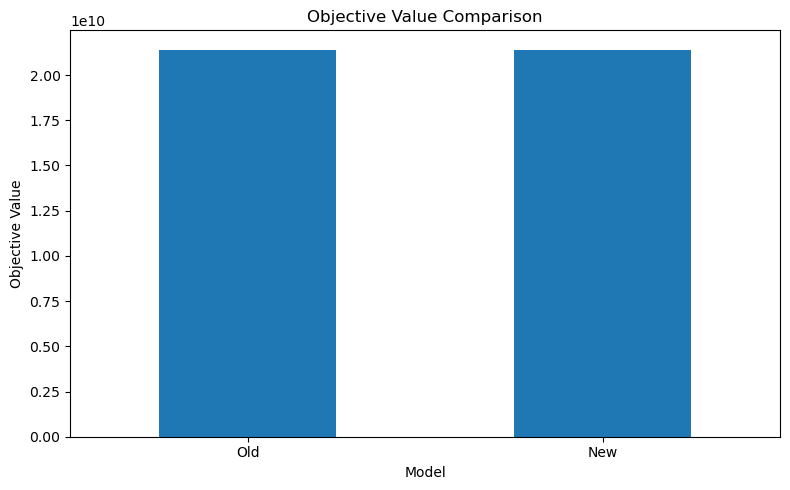

In [360]:
import matplotlib.pyplot as plt

# Plot Objective Values
model_info_df["Objective Value"].plot(
    kind="bar", figsize=(8, 5), title="Objective Value Comparison"
)
plt.ylabel("Objective Value")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

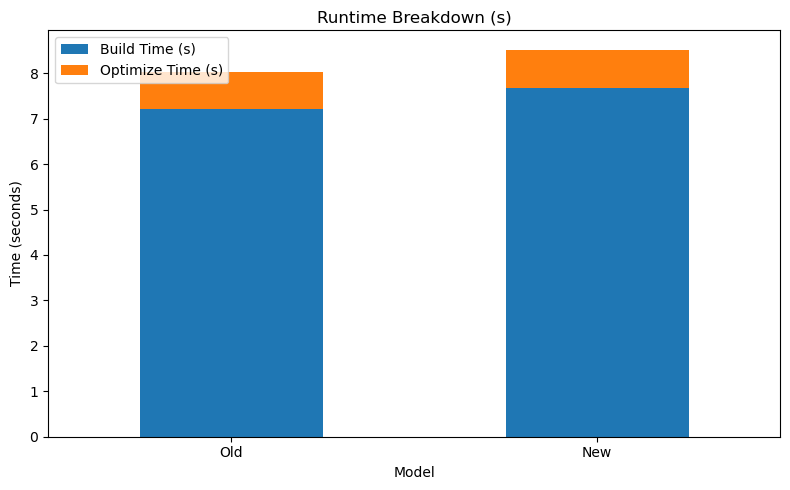

In [361]:
# Plot Runtime Breakdown
model_info_df[["Build Time (s)", "Optimize Time (s)"]].plot(
    kind="bar", stacked=True, figsize=(8, 5), title="Runtime Breakdown (s)"
)
plt.ylabel("Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [362]:
model_info_df

,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
Old,2.140086e+10,NaN,0.789,7.204809,0.816318,8.021127,43428,51498,130209,0,0,0,2
New,2.140086e+10,NaN,0.823,7.669324,0.849243,8.518567,43428,51499,133233,0,0,0,2


In [363]:
decision_variables = {
    display_names[i]: utils.load_csv_files_from_folder_multi(
        os.path.join(results_folders_to_explore[i], "decision_variables")
    )
    for i in range(len(results_folders_to_explore))
}
old = decision_variables[display_names[0]]
new = decision_variables[display_names[1]]

In [364]:
old_generation = old["generation"].copy()
new_generation = new["generation"].copy()
print(old_generation["value"].sum())
print(new_generation["value"].sum())

62658657.88568838
62658657.88568838


In [365]:
print(old["power_flow"]["value"].sum())
print(new["power_flow"]["value"].sum())

-10063246.889258232
-10063246.889258232


In [366]:
dual_variables = utils.load_csv_files_from_folder_multi(
    os.path.join(results_folders_to_explore[1], "dual_variables")
)

In [367]:
keys = list(dual_variables.keys())
keys

['emissions_dual',
 'gen_output_new_duals',
 'gen_output_old_duals',
 'load_shedding_duals',
 'power_balance_duals']

In [368]:
dual_variables[keys[4]]

week   node  dual_value
year hour                         
2025 0       21  ES1 0  496.199856
     1       21  ES1 0  496.199856
     2       21  ES1 0  502.069497
     3       21  ES1 0  502.069497
     4       21  ES1 0  502.069497
...         ...    ...         ...
2045 163     42  PT1 0  485.595108
     164     42  PT1 0  485.595108
     165     42  PT1 0  485.595108
     166     42  PT1 0  485.595108
     167     42  PT1 0  485.595108

[2016 rows x 3 columns]

In [369]:
print(
    "Emissions Dual Value (€/tCO2):",
    dual_variables["emissions_dual"]["dual_value"].iloc[0],
)

Emissions Dual Value (€/tCO2): 0.0


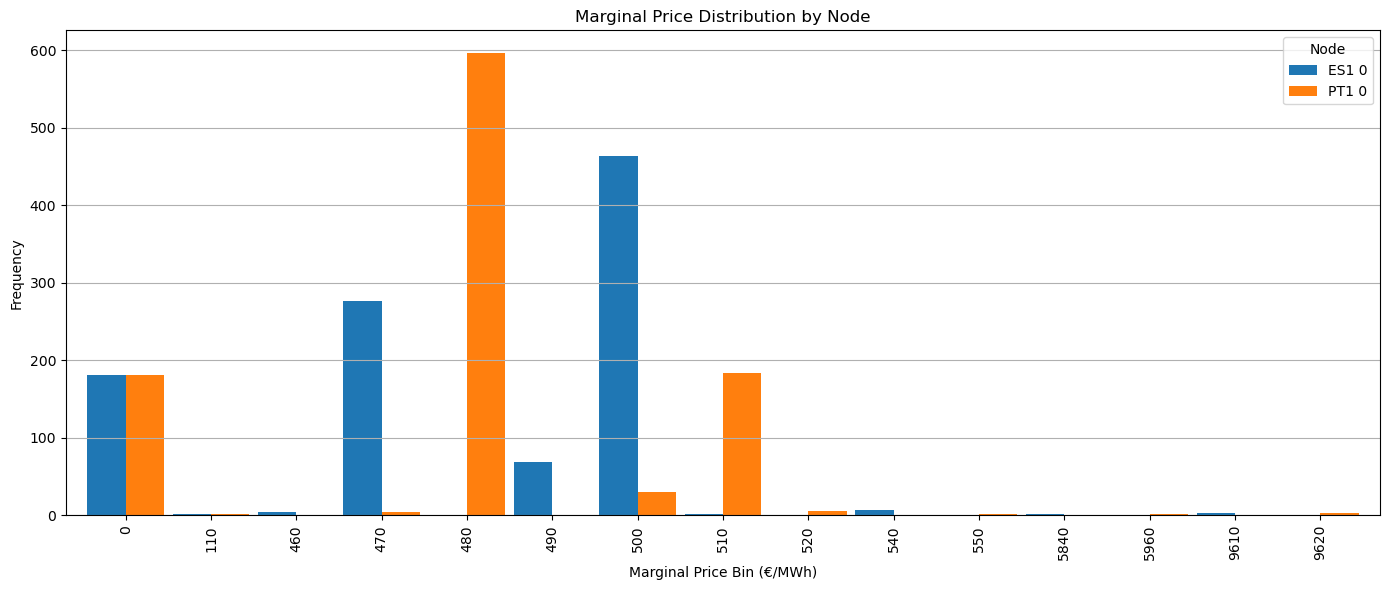

In [370]:
def plot_price_frequency_per_node(
    dual_variables,
    nodes_to_plot=None,
    bin_width=10,
    title="Marginal Price Distribution by Node",
):
    """
    Plot a frequency diagram of marginal prices for each node.

    Parameters:
    - dual_variables: dict containing 'power_balance_duals' DataFrame
    - nodes_to_plot: list of node names (optional). If None, uses the first 3.
    - bin_width: price bin width for histogram (e.g., 10 €/MWh)
    - title: plot title
    """
    df = dual_variables["power_balance_duals"].copy().reset_index()

    if nodes_to_plot is None:
        nodes_to_plot = df["node"].unique()[:3]

    # Round dual values to bin centers
    df["price_bin"] = (df["dual_value"] // bin_width * bin_width).astype(int)

    # Filter to selected nodes
    df = df[df["node"].isin(nodes_to_plot)]

    # Count occurrences per (node, price_bin)
    freq_df = df.groupby(["node", "price_bin"]).size().reset_index(name="count")

    # Pivot for plotting
    pivot_df = freq_df.pivot(index="price_bin", columns="node", values="count").fillna(
        0
    )

    # Sort bins
    pivot_df = pivot_df.sort_index()

    # Plot
    pivot_df.plot(kind="bar", figsize=(14, 6), width=0.9)
    plt.xlabel("Marginal Price Bin (€/MWh)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend(title="Node")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


# Call the function
plot_price_frequency_per_node(
    dual_variables, nodes_to_plot=["ES1 0", "PT1 0"], bin_width=10
)

In [371]:
unique_power_balance_duals = dual_variables["power_balance_duals"][
    "dual_value"
].unique()

In [372]:
generators = pd.read_csv(
    os.path.join(
        os.path.dirname(os.getcwd()),
        "data",
        "processed",
        "elec_s_37_ES_PT_no_bat_limit",
        "generators.csv",
    ),
    index_col=0,
)
branches = pd.read_csv(
    os.path.join(
        os.path.dirname(os.getcwd()),
        "data",
        "processed",
        "elec_s_37_ES_PT_no_bat_limit",
        "branches.csv",
    ),
    index_col=0,
)
batteries = pd.read_csv(
    os.path.join(
        os.path.dirname(os.getcwd()),
        "data",
        "processed",
        "elec_s_37_ES_PT_no_bat_limit",
        "batteries.csv",
    ),
    index_col=0,
)
hourly_demand = pd.read_csv(
    os.path.join(
        os.path.dirname(os.getcwd()),
        "data",
        "processed",
        "elec_s_37_ES_PT_no_bat_limit",
        "hourly_demand.csv",
    ),
    index_col=0,
)
co2_price = 85

In [373]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()),
    "data",
    "processed",
    "elec_s_37_ES_PT_no_bat_limit",
)

In [374]:
input_data_folder

'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\data\\processed\\elec_s_37_ES_PT_no_bat_limit'

In [375]:
years = [2025, 2035, 2045]
weeks = [21, 42]
data_input_yearly_dict = utils.load_multi_year_csv_files_with_week_from_folder(
    years, weeks, input_data_folder
)
data_input_yearly_dict.keys()

dict_keys(['batteries', 'branches', 'capacity_factors', 'generators', 'generator_costs', 'hourly_demand', 'nodes'])

In [376]:
data_input_yearly_dict["hourly_demand"]

ES1 0    PT1 0  week  month  hour
year week hour                                          
2025 1    0     22487.942029   4750.0     1      1     0
          1     20929.623769   4557.0     1      1     1
          2     19488.766684   4262.0     1      1     2
          3     18583.336790   4002.0     1      1     3
          4     18251.508970   3852.0     1      1     4
...                      ...      ...   ...    ...   ...
2045 1    187   89672.797824  19452.0     3     36    57
          188   84322.441285  17607.0     3     36    60
          189   77668.265699  16629.0     3     36    63
          190   74358.797083  16173.0     3     36    66
          191   71075.757230  15417.0     3     36    69

[26280 rows x 5 columns]

In [377]:
# Calculate production cost for each generator
generators_test = generators.copy()
generators_test["production_cost"] = (
    generators_test["marginal_cost"] + generators_test["co2_emissions"] * co2_price
).round(4)

In [378]:
generators_test["production_cost"]

generator
ES1 0 CCGT          57.7724
ES1 0 coal          57.0970
ES1 0 offwind-ac     0.0150
ES1 0 onwind         0.0150
ES1 0 ror            0.0000
ES1 0 solar          0.0100
PT1 0 CCGT          55.8767
PT1 0 offwind-ac     0.0150
PT1 0 onwind         0.0150
PT1 0 ror            0.0000
PT1 0 solar          0.0100
Name: production_cost, dtype: float64

In [379]:
print([round(x, 4) for x in unique_power_balance_duals])

[496.1999, 502.0695, 475.8832, 0.1304, 0.1304, 0.1277, 116.6763, 544.4955, 462.9492, 516.0964, 9615.3886, 5846.3193, 506.3264, 512.3158, 485.5951, 0.133, 0.133, 119.0574, 472.3972, 526.629, 509.8816, 555.6076, 9625.1177, 5965.632]


In [380]:
dual_variables["gen_output_new_duals"]["dual_value"].value_counts()

dual_value
 0.000000       2592
-485.464751     1192
-501.939139      926
-485.508203      596
-485.595108      596
                ... 
-5846.319326       1
-116.676291        1
-5350.119470       1
-5344.249830       1
-5965.545061       1
Name: count, Length: 88, dtype: int64

In [381]:
# Where generator limits are binding
binding_gens = dual_variables["gen_output_old_duals"]
binding_gens = binding_gens[binding_gens["dual_value"] < -1e-3]
print(binding_gens.sort_values("dual_value", ascending=False).head())

           week         generator  dual_value
year hour                                    
2035 131     21  PT1 0 offwind-ac    -0.00266
2025 135     21      PT1 0 onwind    -0.00266
     63      21      PT1 0 onwind    -0.00266
     62      21      PT1 0 onwind    -0.00266
     156     42  PT1 0 offwind-ac    -0.00266


In [382]:
with pd.option_context("display.max_rows", None):
    print(dual_variables["power_balance_duals"]["dual_value"].value_counts())

dual_value
485.595108     596
502.069497     463
475.883206     277
512.315813     184
0.130357       127
0.133017       121
496.199856      69
0.130357        54
0.133017        54
506.326383      29
544.495497       7
0.127750         6
526.628985       6
462.949245       4
472.397189       4
9615.388646      3
9625.117656      3
516.096406       2
555.607650       2
5846.319326      1
116.676291       1
119.057439       1
509.881597       1
5965.631965      1
Name: count, dtype: int64


In [383]:
def explain_dual_at_node_time(
    dual_variables,
    node,
    year,
    week,
    hour,
    data_dict,
    co2_price,
    capacity_factors,
    data_input_yearly_dict,
):
    """
    Provide diagnostics on what might be setting the marginal price at a specific (node, time).

    Parameters:
    - dual_variables: dictionary of dual DataFrames
    - node, year, week, hour: time and location of interest
    - data_dict: dict with generation, curtailment, battery operation, and generator_capacity
    - co2_price: float
    - capacity_factors: DataFrame (multi-indexed by year, week, hour; columns are generator names)
    - data_input_yearly_dict: dictionary with 'generators', 'batteries', 'hourly_demand'
    """

    # Extract LMP (dual value)
    dual_df = dual_variables["power_balance_duals"].reset_index()
    lmp_row = dual_df[
        (dual_df["year"] == year)
        & (dual_df["week"] == week)
        & (dual_df["hour"] == hour)
        & (dual_df["node"] == node)
    ]
    if lmp_row.empty:
        print("⚠️ No dual value found for the specified node/time.")
        return

    lmp = lmp_row["dual_value"].values[0]
    print(f"\n🔍 Marginal Price at {node}, {year}-W{week} Hour {hour}: €{lmp:.2f}/MWh")

    # Input data
    generators = data_input_yearly_dict["generators"]
    batteries = data_input_yearly_dict["batteries"]
    hourly_demand = data_input_yearly_dict["hourly_demand"]

    # Result data
    g_vals = data_dict["generation"]
    sh_vals = data_dict["load_shedding"]
    curtail = data_dict["curtailment"]
    gch = data_dict["battery_charging"]
    gdis = data_dict["battery_discharging"]
    soc = data_dict["battery_soc"]
    generator_capacity = data_dict["generator_capacity"]

    # Demand
    total_demand = hourly_demand.loc[(year, week, hour), node]
    print(f"  - Demand: {total_demand:.2f} MW")

    # Load shedding
    ls = sh_vals.query(
        "year == @year and week == @week and hour == @hour and node == @node"
    )["value"].sum()
    print(f"  - Load Shedding: {ls:.2f} MW")

    # Generation
    gens_this_year = generators.loc[year]
    gens_at_node = gens_this_year[gens_this_year["bus"] == node]

    print("  - Generators at node:")
    total_production = 0
    total_production_cost = 0

    for i in gens_at_node.index:
        gen = g_vals.query(
            "year == @year and week == @week and hour == @hour and generator == @i"
        )["value"].sum()

        p_nom = generators.loc[i, "p_nom"]
        try:
            p_ext = generator_capacity.set_index(["year", "generator"]).loc[
                (year, i), "value"
            ]
        except KeyError:
            p_ext = 0.0

        # Capacity factor from wide-format dataframe
        try:
            cap_factor = capacity_factors.loc[(year, week, hour), i]
        except KeyError:
            cap_factor = 1.0  # fallback if missing
        max_output = (p_nom + p_ext) * cap_factor

        prod_cost = (
            generators.loc[i, "marginal_cost"]
            + co2_price * generators.loc[i, "co2_emissions"]
        )
        total_production += gen
        total_production_cost += gen * prod_cost

        at_limit = " (at max capacity)" if abs(gen - max_output) < 1e-3 else ""
        print(
            f"    - {i}: {gen:.2f} / {max_output:.2f} MW at €{prod_cost:.2f}/MWh{at_limit}"
        )

    print(f"  - Total Generation: {total_production:.2f} MW")
    print(f"  - Total Production Cost: €{total_production_cost:.2f}")

    # Batteries
    bats_this_year = batteries.loc[year]
    bats_at_node = bats_this_year[bats_this_year["node"] == node]

    if bats_at_node.empty:
        print("  - No batteries at node.")
    else:
        for s in bats_at_node.index:
            ch_mask = (
                (gch.index.get_level_values("year") == year)
                & (gch.index.get_level_values("hour") == hour)
                & (gch["week"] == week)
                & (gch["battery"] == s)
            )
            dis_mask = (
                (gdis.index.get_level_values("year") == year)
                & (gdis.index.get_level_values("hour") == hour)
                & (gdis["week"] == week)
                & (gdis["battery"] == s)
            )

            charge_row = gch[ch_mask]
            discharge_row = gdis[dis_mask]

            charge = charge_row["value"].values[0] if not charge_row.empty else 0.0
            discharge = (
                discharge_row["value"].values[0] if not discharge_row.empty else 0.0
            )

            print(f"  - Battery {s}: charge {charge:.2f}, discharge {discharge:.2f}")

    # Curtailment
    curtailed = curtail.query(
        "year == @year and week == @week and hour == @hour and generator.str.startswith(@node)"
    )["value"].sum()
    print(f"  - Total Curtailment: {curtailed:.2f} MW")

In [384]:
explain_dual_at_node_time(
    dual_variables=dual_variables,
    node="ES1 0",
    year=2025,
    week=21,
    hour=17,
    data_dict=new_decision_variables,
    co2_price=co2_price,
    capacity_factors=data_input_yearly_dict["capacity_factors"],
    data_input_yearly_dict=data_input_yearly_dict,
)


🔍 Marginal Price at ES1 0, 2025-W21 Hour 17: €496.20/MWh
  - Demand: 27737.48 MW
  - Load Shedding: 0.00 MW
  - Generators at node:


KeyError: 'ES1 0 CCGT'

In [ ]:
decision_variables[display_names[1]]["battery_discharging"]

week    battery  value
year hour                        
2025 0       21  ES1 0 bat    0.0
     1       21  ES1 0 bat    0.0
     2       21  ES1 0 bat    0.0
     3       21  ES1 0 bat    0.0
     4       21  ES1 0 bat    0.0
...         ...        ...    ...
2045 163     42  PT1 0 bat    0.0
     164     42  PT1 0 bat    0.0
     165     42  PT1 0 bat    0.0
     166     42  PT1 0 bat    0.0
     167     42  PT1 0 bat    0.0

[2016 rows x 3 columns]

In [ ]:
new_decision_variables["generator_capacity"]

,generator,value
year,,
2025,ES1 0 CCGT,0.000000
2035,ES1 0 CCGT,17271.441595
2045,ES1 0 CCGT,14900.146708
2025,ES1 0 coal,0.000000
2035,ES1 0 coal,0.000000
2045,ES1 0 coal,0.000000
2025,ES1 0 offwind-ac,18548.926971
2035,ES1 0 offwind-ac,0.000000
2045,ES1 0 offwind-ac,0.000000


In [ ]:
data_input_yearly_dict["capacity_factors"]

ES1 0 offwind-ac  ES1 0 onwind  ES1 0 ror  ES1 0 solar  \
year week hour                                                           
2025 1    0             0.169080      0.198307   0.223631          0.0   
          1             0.180396      0.183442   0.209677          0.0   
          2             0.187817      0.173403   0.198885          0.0   
          3             0.198432      0.160254   0.187313          0.0   
          4             0.218048      0.156526   0.179705          0.0   
...                          ...           ...        ...          ...   
2045 1    187           0.177343      0.219160   0.300193          0.0   
          188           0.181897      0.228008   0.288119          0.0   
          189           0.190584      0.231160   0.279827          0.0   
          190           0.244625      0.273985   0.273984          0.0   
          191           0.259790      0.272601   0.269047          0.0   

                PT1 0 offwind-ac  PT1 0 onwind  PT1 0 ror  PT1 0 solar  \
year week hour                                                           
2025 1    0             0.223462      0.140790   0.108399          0.0   
          1             0.242486      0.109833   0.104136          0.0   
          2             0.251477      0.101679   0.100124          0.0   
          3             0.246618      0.098385   0.094812          0.0   
          4             0.247457      0.103719   0.089900          0.0   
...                          ...           ...        ...          ...   
2045 1    187           0.196510      0.116910   0.636055          0.0   
          188           0.187475      0.109712   0.621952          0.0   
          189           0.172794      0.102505   0.611703          0.0   
          190           0.238736      0.138531   0.601698          0.0   
          191           0.191602      0.125415   0.594096          0.0   

                ES1 0 CCGT  PT1 0 CCGT  ES1 0 coal  week  month  hour  
year week hour                                                         
2025 1    0            1.0         1.0         1.0     1      1     0  
          1            1.0         1.0         1.0     1      1     1  
          2            1.0         1.0         1.0     1      1     2  
          3            1.0         1.0         1.0     1      1     3  
          4            1.0         1.0         1.0     1      1     4  
...                    ...         ...         ...   ...    ...   ...  
2045 1    187          1.0         1.0         1.0     1     12    19  
          188          1.0         1.0         1.0     1     12    20  
          189          1.0         1.0         1.0     1     12    21  
          190          1.0         1.0         1.0     1     12    22  
          191          1.0         1.0         1.0     1     12    23  

[26280 rows x 14 columns]